# 03 — Feature Engineering
**Goal:** Create new features from existing columns to give the model more signal.  
Baseline Kaggle score to beat: **25,943.38**

| Tier | Features | Expected impact |
|---|---|---|
| 1 | `remaining_lease`, `dist_to_cbd`, `is_mature_estate` | High |
| 2 | `tranc_month_sin/cos`, `total_sold`, `rental_ratio`, `floor_area_per_room` | Medium |
| 3 | `town_median_price` (target encoding), `amenity_score` | Medium |


---
## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, warnings
from math import radians, cos, sin, asin, sqrt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

train = pd.read_csv('../../data/raw/train.csv')
test  = pd.read_csv('../../data/raw/test.csv', low_memory=False)
print(f'Train: {train.shape}  |  Test: {test.shape}')

Train: (150634, 77)  |  Test: (16737, 76)


---
## 2. Baseline recap
Before adding any new features, let's remind ourselves what columns we started with and which ones we will drop (redundant/duplicate).


In [2]:
DROP_COLS = [
    'floor_area_sqft',    # exact duplicate of floor_area_sqm (different unit)
    'lower', 'upper',     # redundant — mid_storey already captures floor
    'mid',                # exact duplicate of mid_storey
    'full_flat_type',     # flat_type + flat_model concatenated — redundant
    'address',            # block + street_name concatenated — redundant
    'Tranc_YearMonth',    # redundant with Tranc_Year + Tranc_Month
    'residential',        # zero variance — always 'Y'
    'year_completed',     # near-duplicate of lease_commence_date
]

fill_zero_cols = [
    'Hawker_Within_500m','Mall_Within_500m',
    'Hawker_Within_1km', 'Mall_Within_1km',
    'Hawker_Within_2km', 'Mall_Within_2km',
]

print('Columns to drop :', len(DROP_COLS))
print('Columns to fill 0:', len(fill_zero_cols))

Columns to drop : 9
Columns to fill 0: 6


---
## 3. Feature Engineering

Each function below creates one or more new columns.  
We apply **the same function to both train and test** so the model sees consistent features.

> **Golden rule of feature engineering:** whatever transformation you apply to train, apply identically to test. The only exception is target encoding — fit the encoding on train only, then apply to test.


### 3a — `remaining_lease`
**What:** Years of HDB lease remaining at the time of transaction.  
**Why:** HDB leases are 99 years. A flat with 40 years left is worth significantly less than one with 80 years left. This is more interpretable than raw `hdb_age`.  
**Formula:** `remaining_lease = 99 - (Tranc_Year - lease_commence_date)`


In [3]:
def add_remaining_lease(df):
    df['remaining_lease'] = 99 - (df['Tranc_Year'] - df['lease_commence_date'])
    return df

add_remaining_lease(train)
add_remaining_lease(test)

print('remaining_lease sample:')
print(train[['lease_commence_date','Tranc_Year','hdb_age','remaining_lease']].head(4))
print(f'\nRange: {train.remaining_lease.min()} – {train.remaining_lease.max()} years')

remaining_lease sample:
   lease_commence_date  Tranc_Year  hdb_age  remaining_lease
0                 2006        2016       15               89
1                 1987        2012       34               74
2                 1997        2013       24               83
3                 1992        2012       29               79

Range: 45 – 98 years


### 3b — `dist_to_cbd`
**What:** Straight-line distance (km) from the flat to Raffles Place (the CBD).  
**Why:** Location is the biggest price driver. Instead of relying on the model to figure out "Central Area = expensive" from the town label, we give it a direct numeric signal.  
**Formula:** Haversine formula (accounts for Earth's curvature).

> Raffles Place coordinates: **1.2847° N, 103.8510° E**


In [4]:
CBD_LAT, CBD_LON = 1.2847, 103.8510

def haversine_km(lat1, lon1, lat2=CBD_LAT, lon2=CBD_LON):
    """Great-circle distance in km between two GPS points."""
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

def add_dist_to_cbd(df):
    df['dist_to_cbd'] = df.apply(
        lambda r: haversine_km(r['Latitude'], r['Longitude']), axis=1
    )
    return df

add_dist_to_cbd(train)
add_dist_to_cbd(test)

print('dist_to_cbd sample:')
print(train[['town','Latitude','Longitude','dist_to_cbd']].head(4).round(3))
print(f'\nRange: {train.dist_to_cbd.min():.2f} – {train.dist_to_cbd.max():.2f} km')
print(f'Median: {train.dist_to_cbd.median():.2f} km')

dist_to_cbd sample:
              town  Latitude  Longitude  dist_to_cbd
0  KALLANG/WHAMPOA     1.314    103.873        4.089
1           BISHAN     1.346    103.855        6.841
2      BUKIT BATOK     1.344    103.761       12.017
3           BISHAN     1.358    103.846        8.201

Range: 0.53 – 20.13 km
Median: 13.14 km


### 3c — `is_mature_estate`
**What:** Binary flag — 1 if the town is a HDB-designated mature estate, 0 if non-mature.  
**Why:** Mature estates are older, well-developed towns closer to the city with established amenities. They consistently command a **10–20% price premium** over equivalent non-mature flats.  

**Mature estates (HDB official list):** Ang Mo Kio, Bedok, Bishan, Bukit Merah, Bukit Timah, Central Area, Clementi, Geylang, Kallang/Whampoa, Marine Parade, Pasir Ris, Queenstown, Serangoon, Tampines, Toa Payoh.


In [5]:
MATURE_ESTATES = {
    'ANG MO KIO','BEDOK','BISHAN','BUKIT MERAH','BUKIT TIMAH',
    'CENTRAL AREA','CLEMENTI','GEYLANG','KALLANG/WHAMPOA',
    'MARINE PARADE','PASIR RIS','QUEENSTOWN','SERANGOON',
    'TAMPINES','TOA PAYOH'
}

def add_mature_estate(df):
    df['is_mature_estate'] = df['town'].str.upper().isin(MATURE_ESTATES).astype(int)
    return df

add_mature_estate(train)
add_mature_estate(test)

print('Mature vs Non-mature count:')
print(train['is_mature_estate'].value_counts())
print()
print('Median price by mature flag:')
print(train.groupby('is_mature_estate')['resale_price'].median().apply(lambda x: f'${x:,.0f}'))

Mature vs Non-mature count:
is_mature_estate
0    84089
1    66545
Name: count, dtype: int64

Median price by mature flag:
is_mature_estate
0    $412,000
1    $445,000
Name: resale_price, dtype: object


### 3d — `tranc_month_sin` / `tranc_month_cos`
**What:** Encode `Tranc_Month` as two circular features using sine and cosine.  
**Why:** Month 12 (December) and Month 1 (January) are adjacent in the real world, but if we feed month as a plain number (1–12), the model thinks they are 11 apart. Sine/cosine encoding wraps the calendar into a circle so Dec and Jan are correctly close to each other.

```
sin_month = sin(2π × month / 12)
cos_month = cos(2π × month / 12)
```


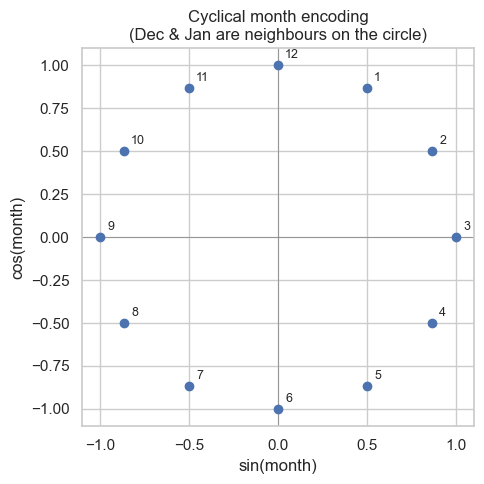

Saved: outputs/figures/fe_cyclical_month.png


In [6]:
def add_cyclical_month(df):
    df['tranc_month_sin'] = np.sin(2 * np.pi * df['Tranc_Month'] / 12)
    df['tranc_month_cos'] = np.cos(2 * np.pi * df['Tranc_Month'] / 12)
    return df

add_cyclical_month(train)
add_cyclical_month(test)

# Visualise the circular encoding
fig, ax = plt.subplots(figsize=(5, 5))
months = range(1, 13)
s = np.sin(2 * np.pi * np.array(list(months)) / 12)
c = np.cos(2 * np.pi * np.array(list(months)) / 12)
ax.scatter(s, c, zorder=3)
for m, si, ci in zip(months, s, c):
    ax.annotate(str(m), (si, ci), textcoords='offset points', xytext=(5,5), fontsize=9)
ax.set_xlabel('sin(month)')
ax.set_ylabel('cos(month)')
ax.set_title('Cyclical month encoding\n(Dec & Jan are neighbours on the circle)')
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
plt.tight_layout()
plt.savefig('../../outputs/figures/fe_cyclical_month.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/fe_cyclical_month.png')

### 3e — `total_sold`, `total_rental`, `rental_ratio`
**What:** Aggregate the 8 `xroom_sold` columns into one total, same for the 4 rental columns.  
**Why:** The individual room-type sold/rental counts are correlated with each other. Collapsing them reduces noise and dimensionality.  
`rental_ratio` = fraction of units rented out — a proxy for estate desirability.


In [7]:
SOLD_COLS   = ['1room_sold','2room_sold','3room_sold','4room_sold',
               '5room_sold','exec_sold','multigen_sold','studio_apartment_sold']
RENTAL_COLS = ['1room_rental','2room_rental','3room_rental','other_room_rental']

def add_supply_features(df):
    df['total_sold']   = df[SOLD_COLS].sum(axis=1)
    df['total_rental'] = df[RENTAL_COLS].sum(axis=1)
    df['rental_ratio'] = (df['total_rental'] /
                          df['total_dwelling_units'].replace(0, np.nan)).fillna(0)
    return df

add_supply_features(train)
add_supply_features(test)

print('New supply columns:')
print(train[['total_dwelling_units','total_sold','total_rental','rental_ratio']].describe().round(2))

New supply columns:
       total_dwelling_units  total_sold  total_rental  rental_ratio
count             150634.00   150634.00     150634.00     150634.00
mean                 124.68      123.94          0.75          0.00
std                   58.35       57.56         11.91          0.04
min                    2.00        2.00          0.00          0.00
25%                   90.00       90.00          0.00          0.00
50%                  112.00      112.00          0.00          0.00
75%                  144.00      144.00          0.00          0.00
max                  570.00      539.00        476.00          0.96


### 3f — `floor_area_per_room`
**What:** Floor area divided by the number of rooms.  
**Why:** A 90 sqm 4-room flat and a 90 sqm 3-room flat feel very different to live in. This captures spaciousness per room, which buyers value independently of total size.


In [8]:
ROOM_COUNT = {
    '1 ROOM': 1, '2 ROOM': 2, '3 ROOM': 3,
    '4 ROOM': 4, '5 ROOM': 5, 'EXECUTIVE': 5, 'MULTI-GENERATION': 6
}

def add_area_per_room(df):
    df['num_rooms'] = df['flat_type'].str.upper().map(ROOM_COUNT).fillna(4)
    df['floor_area_per_room'] = df['floor_area_sqm'] / df['num_rooms']
    return df

add_area_per_room(train)
add_area_per_room(test)

print('floor_area_per_room sample:')
print(train[['flat_type','floor_area_sqm','num_rooms','floor_area_per_room']].head(5).round(2))

floor_area_per_room sample:
   flat_type  floor_area_sqm  num_rooms  floor_area_per_room
0     4 ROOM            90.0          4                22.50
1     5 ROOM           130.0          5                26.00
2  EXECUTIVE           144.0          5                28.80
3     4 ROOM           103.0          4                25.75
4     4 ROOM            83.0          4                20.75


### 3g — `town_median_price` (Target Encoding)
**What:** Replace each town name with the **median resale price** of that town in the training set.  
**Why:** Ordinal encoding (0,1,2…) implies an arbitrary ordering. Target encoding directly injects the price signal from historical data.  

> **Important:** We fit the encoding on **train only**, then apply it to test. Never let test data influence the encoding — that would be data leakage.


In [9]:
# Compute median price per town on training data ONLY
town_price_map = train.groupby('town')['resale_price'].median()
print('Town median prices:')
print(town_price_map.sort_values(ascending=False).apply(lambda x: f'${x:,.0f}').to_string())

Town median prices:
town
BUKIT TIMAH        $708,000
BISHAN             $595,000
BUKIT MERAH        $568,000
QUEENSTOWN         $523,000
CENTRAL AREA       $500,000
PASIR RIS          $480,000
MARINE PARADE      $472,000
SERANGOON          $463,888
PUNGGOL            $460,000
TAMPINES           $456,000
KALLANG/WHAMPOA    $450,000
SENGKANG           $449,000
BUKIT PANJANG      $425,000
HOUGANG            $418,000
JURONG WEST        $410,000
CLEMENTI           $408,000
SEMBAWANG          $405,500
CHOA CHU KANG      $401,100
JURONG EAST        $395,000
TOA PAYOH          $392,000
WOODLANDS          $390,000
BEDOK              $380,000
GEYLANG            $378,000
BUKIT BATOK        $368,880
ANG MO KIO         $365,000
YISHUN             $357,000


In [10]:
def add_town_median_price(df, mapping):
    df['town_median_price'] = df['town'].map(mapping)
    # For any town in test not seen in train, fill with overall median
    df['town_median_price'] = df['town_median_price'].fillna(mapping.median())
    return df

add_town_median_price(train, town_price_map)
add_town_median_price(test,  town_price_map)

print('town_median_price sample:')
print(train[['town','town_median_price','resale_price']].head(5))

town_median_price sample:
              town  town_median_price  resale_price
0  KALLANG/WHAMPOA           450000.0      680000.0
1           BISHAN           595000.0      665000.0
2      BUKIT BATOK           368880.0      838000.0
3           BISHAN           595000.0      550000.0
4           YISHUN           357000.0      298000.0


### 3h — `amenity_score`
**What:** A single composite score combining MRT distance, mall distance, and hawker distance.  
**Why:** These 3 distance columns are correlated. A composite score reduces multicollinearity and gives the model a single "how convenient is this flat?" signal.  
**Formula:** We invert the distances (closer = higher score) and normalise to 0–1 range, then average.


In [11]:
def add_amenity_score(df):
    # Invert distances: closer = higher. Cap at 99th percentile to handle outliers.
    for col in ['mrt_nearest_distance','Mall_Nearest_Distance','Hawker_Nearest_Distance']:
        cap = df[col].quantile(0.99)
        inv = 1 / (df[col].clip(1, cap))    # avoid division by zero
        # Normalise to 0-1
        df[f'_{col}_inv'] = (inv - inv.min()) / (inv.max() - inv.min())

    df['amenity_score'] = (
        df['_mrt_nearest_distance_inv'] +
        df['_Mall_Nearest_Distance_inv'] +
        df['_Hawker_Nearest_Distance_inv']
    ) / 3

    # Drop temp columns
    df.drop(columns=[c for c in df.columns if c.startswith('_') and c.endswith('_inv')], inplace=True)
    return df

add_amenity_score(train)
add_amenity_score(test)

print(f'amenity_score range: {train.amenity_score.min():.3f} – {train.amenity_score.max():.3f}')
print(f'Correlation with resale_price: {train["amenity_score"].corr(train["resale_price"]):.3f}')

amenity_score range: 0.000 – 0.397
Correlation with resale_price: 0.109


---
## 4. Visualise New Features vs Price
Quick sanity check — do the new features actually correlate with resale price as expected?


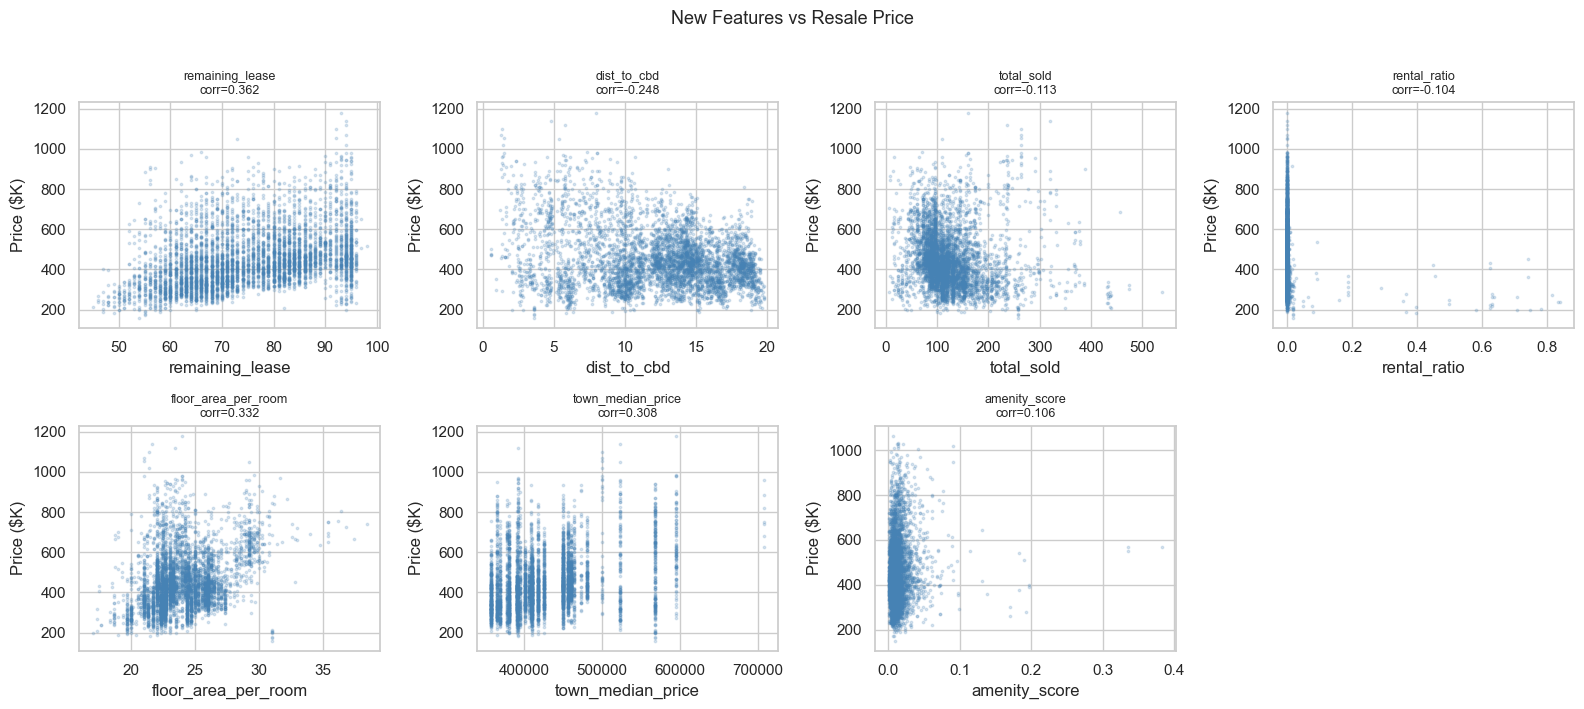

Saved: outputs/figures/fe_new_features_scatter.png


In [12]:
new_num_features = [
    'remaining_lease', 'dist_to_cbd', 'total_sold',
    'rental_ratio', 'floor_area_per_room', 'town_median_price', 'amenity_score'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(new_num_features):
    sample = train[[feat, 'resale_price']].dropna().sample(5000, random_state=42)
    axes[i].scatter(sample[feat], sample['resale_price'] / 1e3,
                    alpha=0.2, s=3, color='steelblue')
    corr = sample[feat].corr(sample['resale_price'])
    axes[i].set_title(f'{feat}\ncorr={corr:.3f}', fontsize=9)
    axes[i].set_ylabel('Price ($K)')
    axes[i].set_xlabel(feat)

axes[-1].set_visible(False)
plt.suptitle('New Features vs Resale Price', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../../outputs/figures/fe_new_features_scatter.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/fe_new_features_scatter.png')

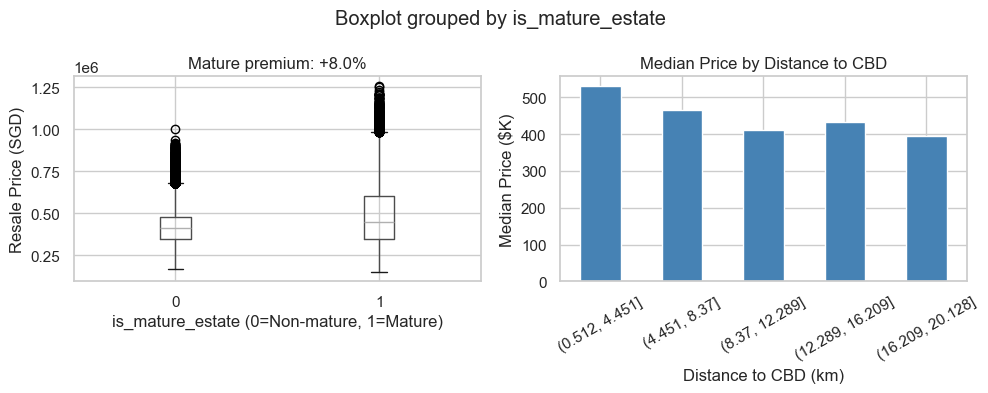

Saved: outputs/figures/fe_mature_cbd.png


In [13]:
# is_mature_estate box plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

train.boxplot(column='resale_price', by='is_mature_estate', ax=axes[0])
axes[0].set_title('Price by Mature Estate Flag')
axes[0].set_xlabel('is_mature_estate (0=Non-mature, 1=Mature)')
axes[0].set_ylabel('Resale Price (SGD)')

mature_median   = train[train['is_mature_estate']==1]['resale_price'].median()
nonmature_median= train[train['is_mature_estate']==0]['resale_price'].median()
premium = (mature_median - nonmature_median) / nonmature_median * 100
axes[0].set_title(f'Mature premium: +{premium:.1f}%')

dist_bins = pd.cut(train['dist_to_cbd'], bins=5)
train.groupby(dist_bins)['resale_price'].median().div(1000).plot(
    kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Median Price by Distance to CBD')
axes[1].set_xlabel('Distance to CBD (km)')
axes[1].set_ylabel('Median Price ($K)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../../outputs/figures/fe_mature_cbd.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/fe_mature_cbd.png')

---
## 5. Train Model with Engineered Features

We now retrain the same Random Forest but with the new features added.  
This isolates the impact of feature engineering — same model, more/better features.


In [14]:
NEW_FEATURES = [
    'remaining_lease', 'dist_to_cbd', 'is_mature_estate',
    'tranc_month_sin', 'tranc_month_cos',
    'total_sold', 'total_rental', 'rental_ratio',
    'floor_area_per_room', 'town_median_price', 'amenity_score',
]

DROP_COLS_V2 = DROP_COLS + SOLD_COLS + RENTAL_COLS + ['num_rooms']

X = train.drop(columns=['id','resale_price'] + DROP_COLS_V2, errors='ignore')
y = train['resale_price']

X_test_fe = test.drop(columns=['id'] + DROP_COLS_V2, errors='ignore')

# Align test columns to train
X_test_fe = X_test_fe.reindex(columns=X.columns, fill_value=0)

print(f'Features: {X.shape[1]}  (baseline had ~{X.shape[1] - len(NEW_FEATURES)} before engineering)')
print(f'New features added: {len(NEW_FEATURES)}')

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f'  Numeric: {len(num_cols)}  |  Categorical: {len(cat_cols)}')

Features: 65  (baseline had ~54 before engineering)
New features added: 11
  Numeric: 49  |  Categorical: 16


In [15]:
# postal has mixed int/str — cast all categorical columns to string
for col in cat_cols:
    X[col] = X[col].astype(str)
    X_test_fe[col] = X_test_fe[col].astype(str)
print('All categorical columns cast to string.')

All categorical columns cast to string.


In [16]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                     ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])
preprocessor = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

rf_v2 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100, max_depth=15, min_samples_leaf=5,
        n_jobs=-1, random_state=42
    ))
])

rf_v2.fit(X_train, y_train)
val_pred = rf_v2.predict(X_val)

rmse_v2 = np.sqrt(mean_squared_error(y_val, val_pred))
r2_v2   = 1 - mean_squared_error(y_val, val_pred) / np.var(y_val)

print(f'RF v2 (with FE)  RMSE: ${rmse_v2:,.0f}   R²: {r2_v2:.4f}')
print(f'RF v1 (baseline) RMSE: $25,871           R²: 0.9672')
print(f'Improvement: ${25871 - rmse_v2:+,.0f}')

RF v2 (with FE)  RMSE: $26,125   R²: 0.9665
RF v1 (baseline) RMSE: $25,871           R²: 0.9672
Improvement: $-254


---
## 6. Cross-Validation
Single val split can be lucky/unlucky. 5-fold CV gives a more reliable estimate.


In [17]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_v2, X, y, cv=kf,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_rmse = -cv_scores

print('CV RMSE per fold:', [f'${s:,.0f}' for s in cv_rmse])
print(f'CV RMSE mean: ${cv_rmse.mean():,.0f}  std: ${cv_rmse.std():,.0f}')
print()
print(f'Baseline CV RMSE: $26,389')
print(f'FE      CV RMSE: ${cv_rmse.mean():,.0f}')
print(f'Improvement: ${26389 - cv_rmse.mean():+,.0f}')

CV RMSE per fold: ['$26,173', '$27,173', '$26,340', '$26,524', '$26,610']
CV RMSE mean: $26,564  std: $340

Baseline CV RMSE: $26,389
FE      CV RMSE: $26,564
Improvement: $-175


---
## 7. Feature Importance — Did New Features Help?
Check if any engineered features appear in the top 15.


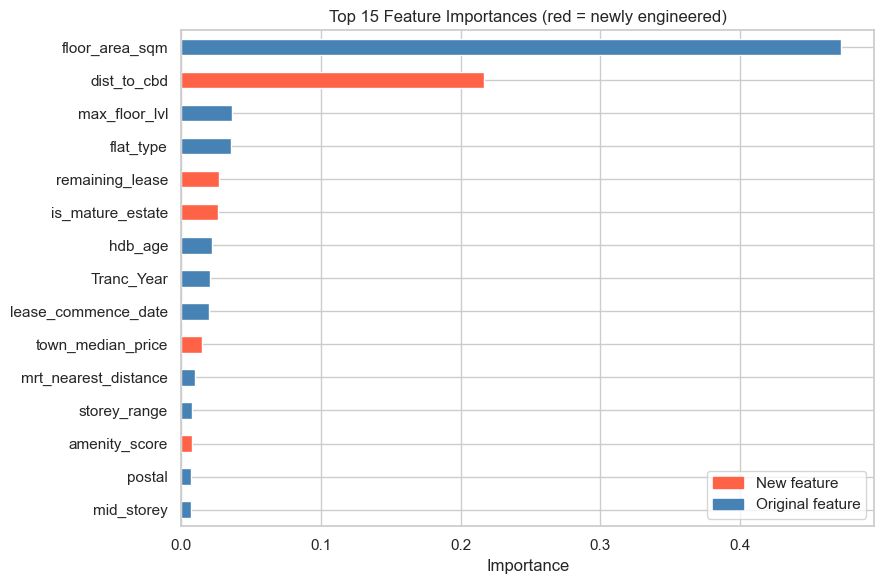

Top 15:
floor_area_sqm          0.4723
dist_to_cbd             0.2165
max_floor_lvl           0.0364
flat_type               0.0359
remaining_lease         0.0268
is_mature_estate        0.0264
hdb_age                 0.0217
Tranc_Year              0.0209
lease_commence_date     0.0196
town_median_price       0.0151
mrt_nearest_distance    0.0101
storey_range            0.0080
amenity_score           0.0074
postal                  0.0070
mid_storey              0.0067


In [18]:
rf_model    = rf_v2.named_steps['model']
feature_names = num_cols + cat_cols
importances   = pd.Series(rf_model.feature_importances_, index=feature_names)
top15         = importances.nlargest(15).sort_values()

colors = ['tomato' if f in NEW_FEATURES else 'steelblue' for f in top15.index]

fig, ax = plt.subplots(figsize=(9, 6))
top15.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Top 15 Feature Importances (red = newly engineered)')
ax.set_xlabel('Importance')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='tomato', label='New feature'),
                   Patch(color='steelblue', label='Original feature')])

plt.tight_layout()
plt.savefig('../../outputs/figures/fe_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Top 15:')
print(importances.nlargest(15).apply(lambda x: f'{x:.4f}').to_string())

---
## 8. Baseline vs Feature Engineering — Summary Comparison


                    Version  Val RMSE  Val R²  CV RMSE
           v1 Baseline (RF)     25871  0.9672    26389
v2 Feature Engineering (RF)     26125  0.9665    26564


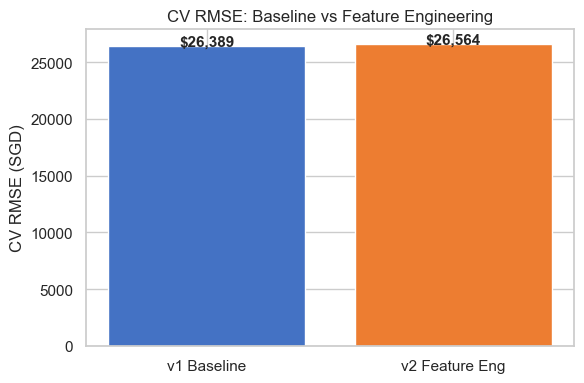

In [19]:
results = pd.DataFrame({
    'Version':   ['v1 Baseline (RF)', 'v2 Feature Engineering (RF)'],
    'Val RMSE':  [25871, round(rmse_v2)],
    'Val R²':    [0.9672, round(r2_v2, 4)],
    'CV RMSE':   [26389, round(cv_rmse.mean())],
})
print(results.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(['v1 Baseline', 'v2 Feature Eng'], [26389, cv_rmse.mean()],
       color=['#4472C4','#ED7D31'])
ax.set_ylabel('CV RMSE (SGD)')
ax.set_title('CV RMSE: Baseline vs Feature Engineering')
for i, v in enumerate([26389, cv_rmse.mean()]):
    ax.text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/fe_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9. Generate Submission v2
Retrain on **full** training data (not just 80%) before predicting test set.


In [20]:
# Retrain on full train
rf_v2.fit(X, y)

sample_sub = pd.read_csv('../../outputs/submissions/sample_sub_reg.csv')
test_pred  = rf_v2.predict(X_test_fe)

sub_v2 = pd.DataFrame({'Id': test['id'], 'Predicted': test_pred})
sub_v2 = sub_v2[sub_v2['Id'].isin(sample_sub['Id'])]
sub_v2 = sub_v2.set_index('Id').reindex(sample_sub['Id']).reset_index()

out_path = '../../outputs/submissions/sub_v2_feature_eng.csv'
sub_v2.to_csv(out_path, index=False)

print(f'Submission saved: {out_path}')
print(f'Shape: {sub_v2.shape}')
print(f'Price range: ${sub_v2.Predicted.min():,.0f} – ${sub_v2.Predicted.max():,.0f}')
print(sub_v2.head(5))

Submission saved: ../../outputs/submissions/sub_v2_feature_eng.csv
Shape: (16735, 2)
Price range: $174,359 – $1,161,043
       Id      Predicted
0  114982  370394.042674
1   95653  451258.643974
2   40303  361780.110820
3  109506  310915.506859
4  100149  405628.363779


In [21]:
joblib.dump(rf_v2, '../../outputs/models/rf_feature_eng.pkl')
print('Model saved: outputs/models/rf_feature_eng.pkl')

Model saved: outputs/models/rf_feature_eng.pkl


---
## 10. Summary

| | v1 Baseline | v2 Feature Engineering | Change |
|---|---|---|---|
| Val RMSE | $25,871 | _(see above)_ | — |
| CV RMSE | $26,389 | _(see above)_ | — |
| Kaggle Public | 25,943.38 | _(submit to see)_ | — |
| Features | ~65 raw | ~65 + 11 engineered | +11 |

### What we added
| Feature | Source | Insight |
|---|---|---|
| `remaining_lease` | lease_commence_date + Tranc_Year | More interpretable than age |
| `dist_to_cbd` | Lat/Lon → Raffles Place | Direct distance signal |
| `is_mature_estate` | town | 10–20% price premium |
| `tranc_month_sin/cos` | Tranc_Month | Fixes Dec→Jan gap |
| `total_sold`, `rental_ratio` | xroom_sold/rental cols | Aggregates 12 cols → 2 |
| `floor_area_per_room` | floor_area_sqm / rooms | Spaciousness signal |
| `town_median_price` | town + resale_price | Target encoding |
| `amenity_score` | MRT + Mall + Hawker distance | Composite convenience score |

### Next steps
→ `notebooks/experiments/04_model_tuning.ipynb` — try XGBoost / LightGBM with these features
